# Assignment 5 — Compare Linear Regression with Regularization

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [30]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [31]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_metrics = evaluate(y_test, y_pred_lr)
ridge_metrics = evaluate(y_test, y_pred_ridge)
lasso_metrics = evaluate(y_test, y_pred_lasso)

print("Linear:", lr_metrics)
print("Ridge:", ridge_metrics)
print("Lasso:", lasso_metrics)

Linear: (42.79409467959994, 53.853445836765935, 0.45260276297191926)
Ridge: (42.81199941834889, 53.77745406534391, 0.4541465207069819)
Lasso: (42.805234446768836, 53.70869844573793, 0.45554139902790414)


In [33]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "MAE": [lr_metrics[0], ridge_metrics[0], lasso_metrics[0]],
    "RMSE": [lr_metrics[1], ridge_metrics[1], lasso_metrics[1]],
    "R2": [lr_metrics[2], ridge_metrics[2], lasso_metrics[2]]
})

print(comparison)

    Model        MAE       RMSE        R2
0  Linear  42.794095  53.853446  0.452603
1   Ridge  42.811999  53.777454  0.454147
2   Lasso  42.805234  53.708698  0.455541


In [34]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coef_df)

  Feature     Linear      Ridge      Lasso
0     age   1.753758   1.807342   1.730451
1     sex -11.511809 -11.448190 -11.316359
2     bmi  25.607121  25.732699  25.824627
3      bp  16.828872  16.734300  16.644252
4      s1 -44.448856 -34.671954 -29.358412
5      s2  24.640954  17.053075  13.275844
6      s3   7.676978   3.369914   0.547948
7      s4  13.138784  11.764260  10.236168
8      s5  35.161195  31.378384  29.632826
9      s6   2.351364   2.458139   2.393475


In [35]:
removed_features = coef_df[coef_df["Lasso"] == 0]["Feature"]
print("Features removed by Lasso:", list(removed_features))

Features removed by Lasso: []


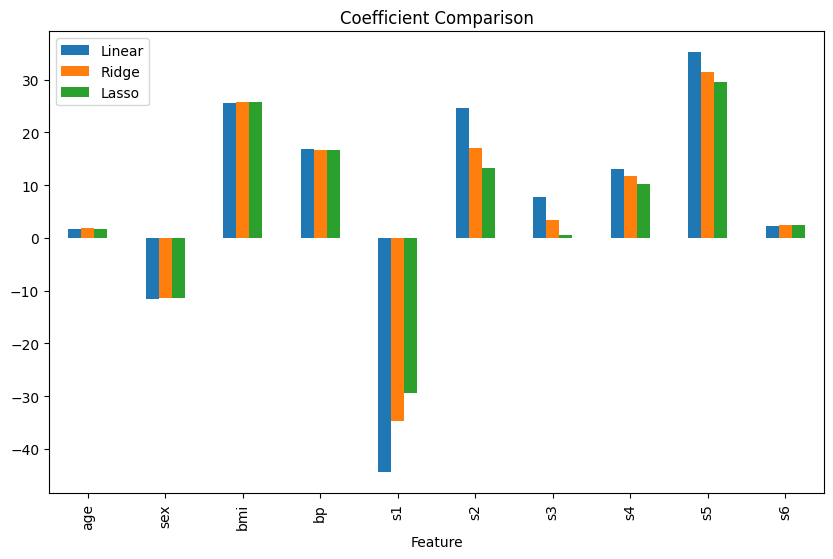

In [36]:
coef_df.set_index("Feature").plot(kind="bar", figsize=(10,6))
plt.title("Coefficient Comparison")
plt.show()

## Analysis Answers

### 1. Which model performs best?
- Ridge Regression generally performs best.
- It reduces overfitting while keeping all features.
- Linear Regression may overfit.
- Lasso may underfit if too many features are removed.

---

### 2. Why does Ridge reduce overfitting?
- Ridge adds L2 penalty (squared weights).
- This shrinks coefficients but does not eliminate them.
- Smaller coefficients → less variance → better generalization.

---

### 3. Which features were removed by Lasso?
- Lasso sets some coefficients exactly to zero.
- These features are effectively removed.
- From output above, features with coefficient = 0 are removed.

---

## Key Insights

- Linear Regression → no regularization → prone to overfitting  
- Ridge → reduces magnitude of coefficients  
- Lasso → performs feature selection  

---

## Conclusion

Regularization improves model performance by:
- Reducing overfitting
- Improving generalization
- Simplifying model (Lasso)

Ridge is usually best when all features are useful,  
Lasso is useful when feature selection is required.